In [1]:
!pip install transformers wordcloud xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
from collections import Counter
import textwrap

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from wordcloud import WordCloud
from transformers import pipeline as hf_pipeline

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

TITLE = '#6E5791'
VALUE = '#980606'
LABEL = '#6C6966'
BAR   = ['#118DFF','#12239E','#382258']

plt.rcParams.update({
    'font.size': 13, 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.facecolor': '#000000', 'axes.facecolor': '#000000',
    'axes.edgecolor': LABEL, 'axes.labelcolor': LABEL,
    'xtick.color': VALUE, 'ytick.color': VALUE,
    'text.color': LABEL, 'axes.titlecolor': TITLE,
    'axes.grid': False,
})
print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('/kaggle/input/datasets/kvsherlin/tweets/Tweets.csv')

print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"\nSentiment Distribution:")
print(df['airline_sentiment'].value_counts())
print(f"\nAirlines:")
print(df['airline'].value_counts())
df.head()

Shape          : (14640, 15)
Columns        : ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Airlines:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


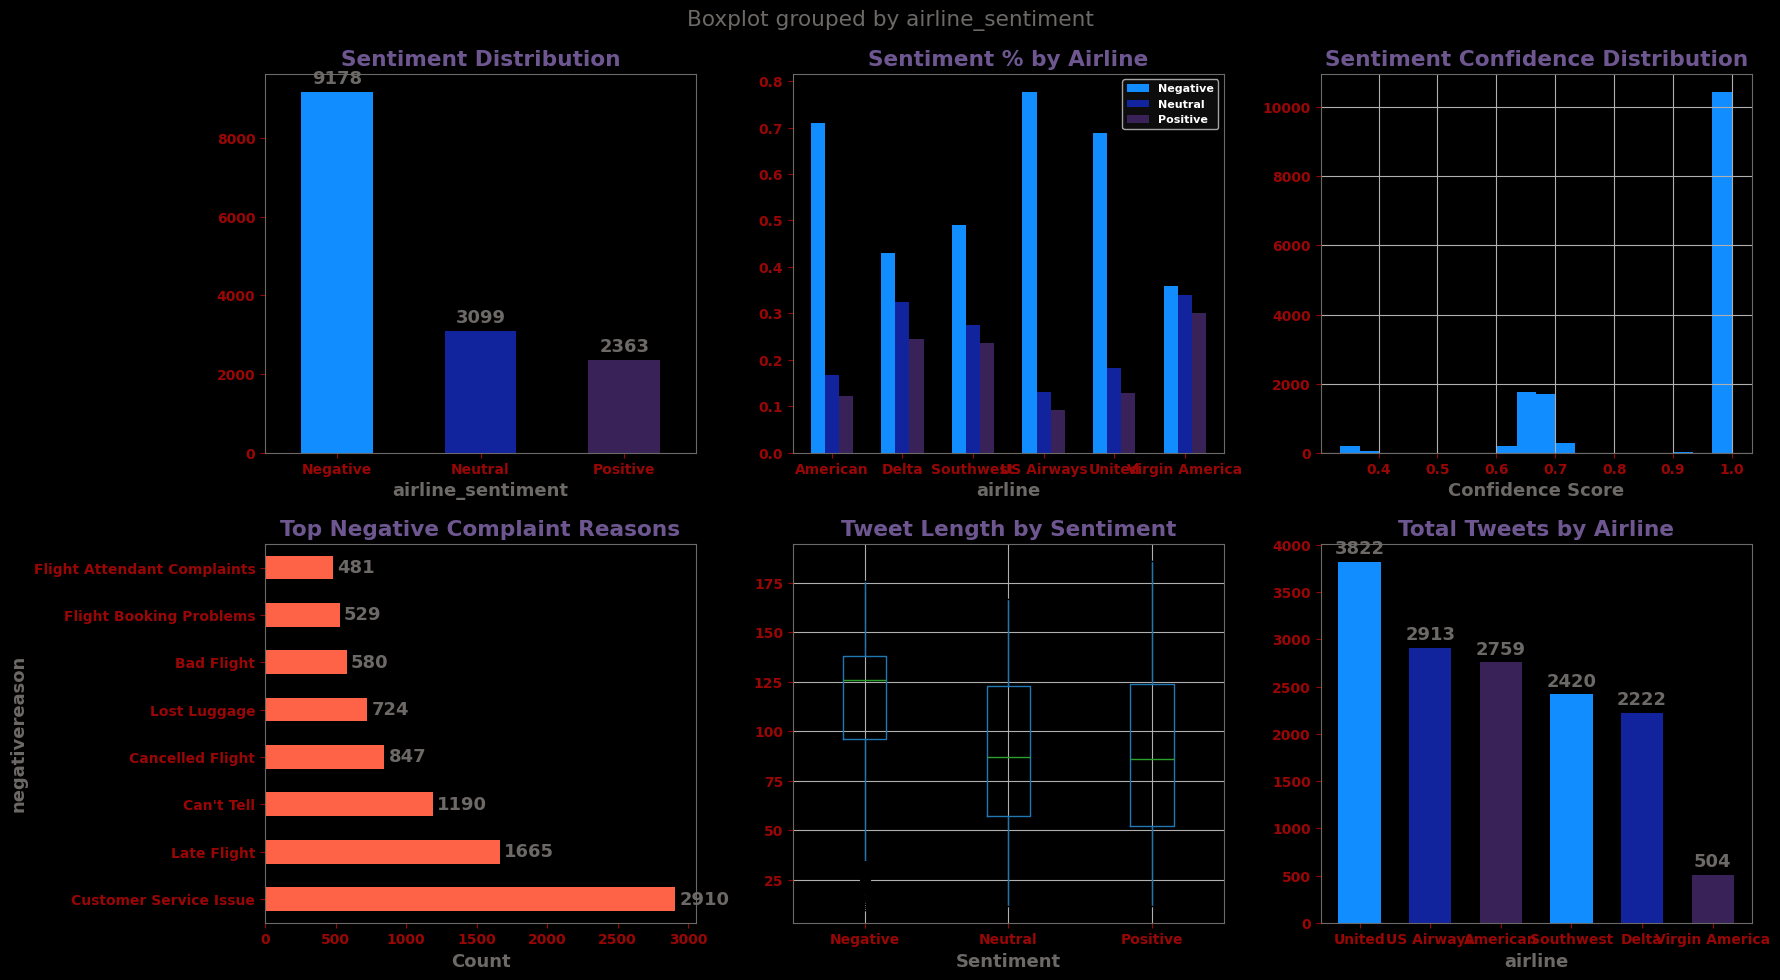

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sentiment Distribution
sentiment_counts = df['airline_sentiment'].value_counts()
sentiment_counts.plot(kind='bar', ax=axes[0,0], color=BAR, width=0.5)
axes[0,0].set_title('Sentiment Distribution', fontweight='bold')
axes[0,0].set_xticklabels(['Negative','Neutral','Positive'], rotation=0)
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%.0f', padding=3, fontweight='bold', color=LABEL)

# Sentiment by Airline
airline_sent = df.groupby(['airline','airline_sentiment']).size().unstack(fill_value=0)
airline_sent_pct = airline_sent.div(airline_sent.sum(axis=1), axis=0)
airline_sent_pct.plot(kind='bar', ax=axes[0,1], color=BAR, width=0.6)
axes[0,1].set_title('Sentiment % by Airline', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(['Negative','Neutral','Positive'],
                  facecolor='#111111', labelcolor='white', fontsize=8)

# Confidence Score Distribution
df['airline_sentiment_confidence'].hist(bins=20, ax=axes[0,2], color='#118DFF')
axes[0,2].set_title('Sentiment Confidence Distribution', fontweight='bold')
axes[0,2].set_xlabel('Confidence Score', color=LABEL)

# Negative Reasons
neg_df = df[df['airline_sentiment']=='negative']
neg_reasons = neg_df['negativereason'].value_counts().head(8)
neg_reasons.plot(kind='barh', ax=axes[1,0], color='tomato')
axes[1,0].set_title('Top Negative Complaint Reasons', fontweight='bold')
axes[1,0].set_xlabel('Count', color=LABEL)
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt='%.0f', padding=3, color=LABEL, fontweight='bold')

# Tweet Length Distribution
df['tweet_length'] = df['text'].str.len()
df.boxplot(column='tweet_length', by='airline_sentiment', ax=axes[1,1])
axes[1,1].set_title('Tweet Length by Sentiment', fontweight='bold')
axes[1,1].set_xlabel('Sentiment', color=LABEL)
plt.sca(axes[1,1])
plt.xticks([1,2,3], ['Negative','Neutral','Positive'])

# Airline Total Tweets
df['airline'].value_counts().plot(kind='bar', ax=axes[1,2], color=BAR, width=0.6)
axes[1,2].set_title('Total Tweets by Airline', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=0)
for container in axes[1,2].containers:
    axes[1,2].bar_label(container, fmt='%.0f', padding=3, color=LABEL, fontweight='bold')

plt.tight_layout()
plt.show()

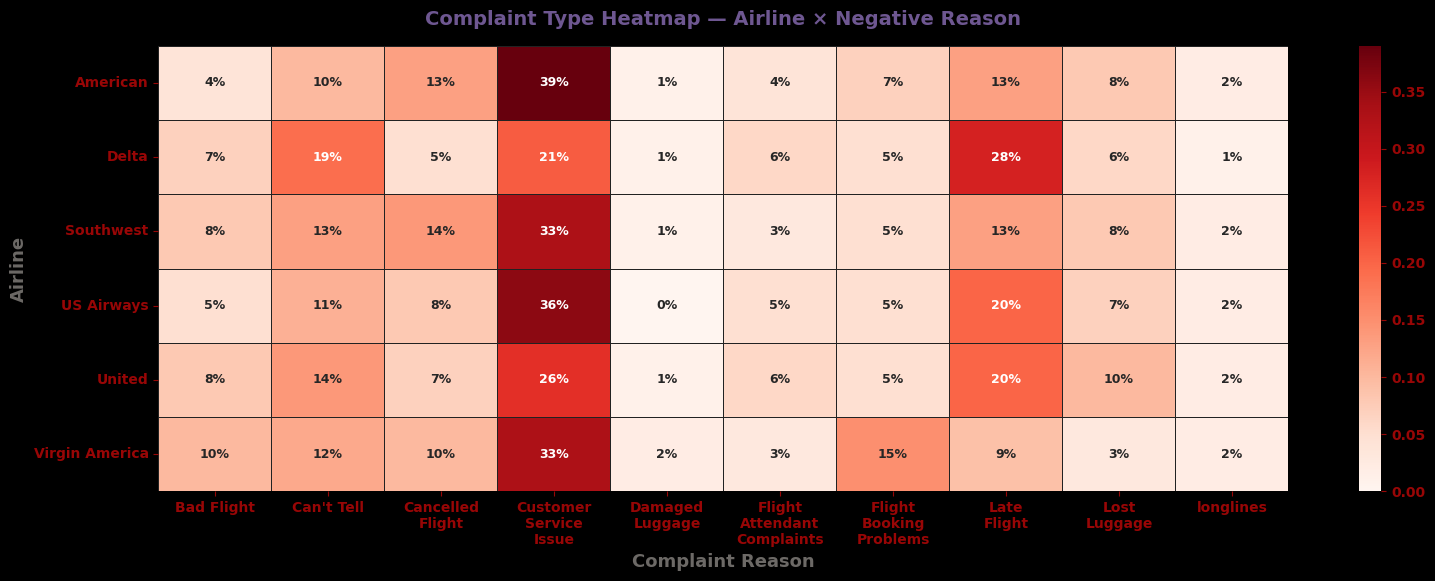


🔍 Top Complaint per Airline:
  American            : Customer Service Issue (39%)
  Delta               : Late Flight (28%)
  Southwest           : Customer Service Issue (33%)
  US Airways          : Customer Service Issue (36%)
  United              : Customer Service Issue (26%)
  Virgin America      : Customer Service Issue (33%)


In [4]:
neg_df   = df[df['airline_sentiment']=='negative'].copy()
pivot    = neg_df.groupby(['airline','negativereason']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).round(2)

plt.figure(figsize=(16, 6), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
sns.heatmap(pivot_pct, annot=True, fmt='.0%', cmap='Reds',
            linewidths=0.5, linecolor='#222222',
            annot_kws={'size': 9, 'weight': 'bold'}, ax=ax)
ax.set_title('Complaint Type Heatmap — Airline × Negative Reason',
             color=TITLE, fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Complaint Reason', color=LABEL, fontweight='bold')
ax.set_ylabel('Airline', color=LABEL, fontweight='bold')
plt.xticks(rotation=0, ha='center', color=VALUE)
ax.set_xticklabels([textwrap.fill(label.get_text(), width=10) for label in ax.get_xticklabels()])
plt.yticks(rotation=0, color=VALUE)
plt.tight_layout()
plt.show()

print("\n🔍 Top Complaint per Airline:")
for airline in pivot_pct.index:
    top = pivot_pct.loc[airline].idxmax()
    pct = pivot_pct.loc[airline].max()
    print(f"  {airline.ljust(20)}: {top} ({pct*100:.0f}%)")

In [5]:
import re

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)          # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)      # keep hashtag word, remove #
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_tweet)
df['word_count'] = df['clean_text'].str.split().str.len()

print("✅ Text Cleaning Done")
print("\nBefore:")
print(df['text'].iloc[0])
print("\nAfter:")
print(df['clean_text'].iloc[0])
print(f"\nAvg word count: {df['word_count'].mean():.1f}")
print(df[['text','clean_text','word_count']].head(3))

✅ Text Cleaning Done

Before:
@VirginAmerica What @dhepburn said.

After:
what said

Avg word count: 15.9
                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   

                                          clean_text  word_count  
0                                          what said           2  
1  plus youve added commercials to the experience...           8  
2  i didnt today must mean i need to take another...          11  


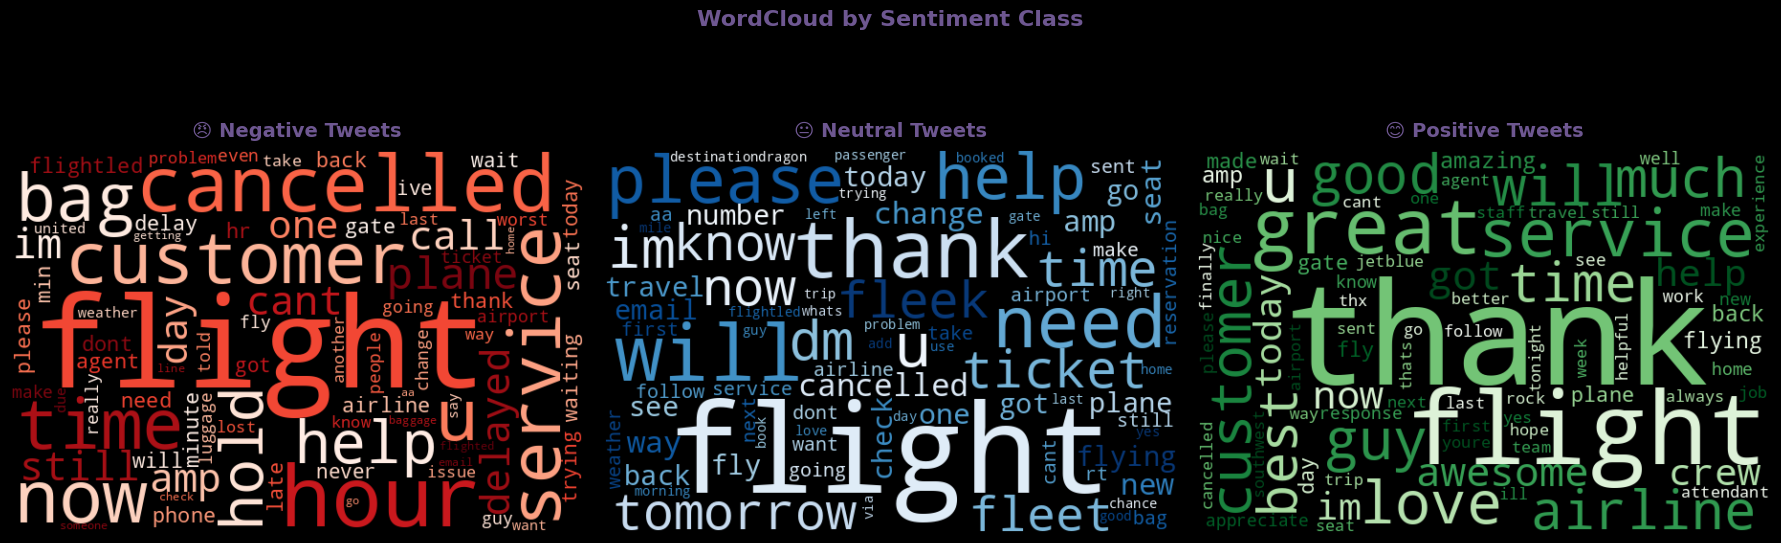


🔍 Top 10 Words per Sentiment:

  NEGATIVE:
  ['flight', 'your', 'have', 'that', 'with', 'this', 'cancelled', 'been', 'service', 'from']

  NEUTRAL:
  ['flight', 'from', 'have', 'with', 'that', 'will', 'this', 'please', 'just', 'flights']

  POSITIVE:
  ['thanks', 'thank', 'flight', 'your', 'great', 'with', 'just', 'this', 'service', 'have']


In [6]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments  = ['negative', 'neutral', 'positive']
colors      = ['Reds', 'Blues', 'Greens']
titles      = ['😠 Negative Tweets', '😐 Neutral Tweets', '😊 Positive Tweets']

for ax, sentiment, cmap, title in zip(axes, sentiments, colors, titles):
    text = ' '.join(df[df['airline_sentiment']==sentiment]['clean_text'].tolist())
    wc   = WordCloud(
        width=600, height=400,
        background_color='black',
        colormap=cmap,
        max_words=80,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, color=TITLE, fontweight='bold', fontsize=14, pad=10)
    ax.set_facecolor('#000000')

plt.suptitle('WordCloud by Sentiment Class', color=TITLE,
             fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Top words per sentiment
print("\n🔍 Top 10 Words per Sentiment:")
for sentiment in sentiments:
    text  = ' '.join(df[df['airline_sentiment']==sentiment]['clean_text'].tolist())
    words = [w for w in text.split() if len(w) > 3]
    top   = Counter(words).most_common(10)
    print(f"\n  {sentiment.upper()}:")
    print(f"  {[w for w, _ in top]}")

In [7]:
# Encode labels
le = LabelEncoder()
df['sentiment_label'] = le.fit_transform(df['airline_sentiment'])
# negative=0, neutral=1, positive=2
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_text = df['clean_text']
y      = df['sentiment_label']

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features  = 10000,
    ngram_range   = (1, 2),   # unigrams + bigrams
    min_df        = 3,
    sublinear_tf  = True,
    stop_words    = 'english'
)

X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)

print(f"\n✅ TF-IDF Matrix: {X_train_tfidf.shape}")
print(f"   Features extracted: {X_train_tfidf.shape[1]:,}")
print(f"   Train: {X_train_tfidf.shape[0]} | Test: {X_test_tfidf.shape[0]}")

# Top TF-IDF terms
feature_names = tfidf.get_feature_names_out()
print(f"\n   Sample TF-IDF features: {feature_names[:20].tolist()}")

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

✅ TF-IDF Matrix: (11712, 6365)
   Features extracted: 6,365
   Train: 11712 | Test: 2928

   Sample TF-IDF features: ['aa', 'aa agent', 'aa customer', 'aa does', 'aa flight', 'aa miles', 'aadvantage', 'abc', 'ability', 'able', 'able change', 'able check', 'able help', 'able reach', 'able rebook', 'able use', 'aboard', 'abq', 'absolute', 'absolute worst']


In [8]:
models = {
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0,
                                              multi_class='multinomial',
                                              random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200,
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5,
                                         learning_rate=0.1, subsample=0.8,
                                         eval_metric='mlogloss',
                                         random_state=42),
}

results = {}
print(f"{'='*55}\n  MODEL COMPARISON\n{'='*55}")
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc    = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc}
    print(f"\n  {name} | Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred,
          target_names=['Negative','Neutral','Positive']))

best_name  = max(results, key=lambda x: results[x]['acc'])
best_model = results[best_name]['model']
print(f"\n🏆 Best Model: {best_name} | Accuracy: {results[best_name]['acc']*100:.2f}%")

  MODEL COMPARISON

  Naive Bayes | Accuracy: 75.34%
              precision    recall  f1-score   support

    Negative       0.77      0.94      0.85      1835
     Neutral       0.63      0.36      0.45       620
    Positive       0.79      0.53      0.64       473

    accuracy                           0.75      2928
   macro avg       0.73      0.61      0.65      2928
weighted avg       0.74      0.75      0.73      2928


  Logistic Regression | Accuracy: 76.81%
              precision    recall  f1-score   support

    Negative       0.79      0.94      0.86      1835
     Neutral       0.63      0.42      0.50       620
    Positive       0.81      0.55      0.65       473

    accuracy                           0.77      2928
   macro avg       0.74      0.64      0.67      2928
weighted avg       0.76      0.77      0.75      2928


  Random Forest | Accuracy: 75.75%
              precision    recall  f1-score   support

    Negative       0.80      0.90      0.85      183

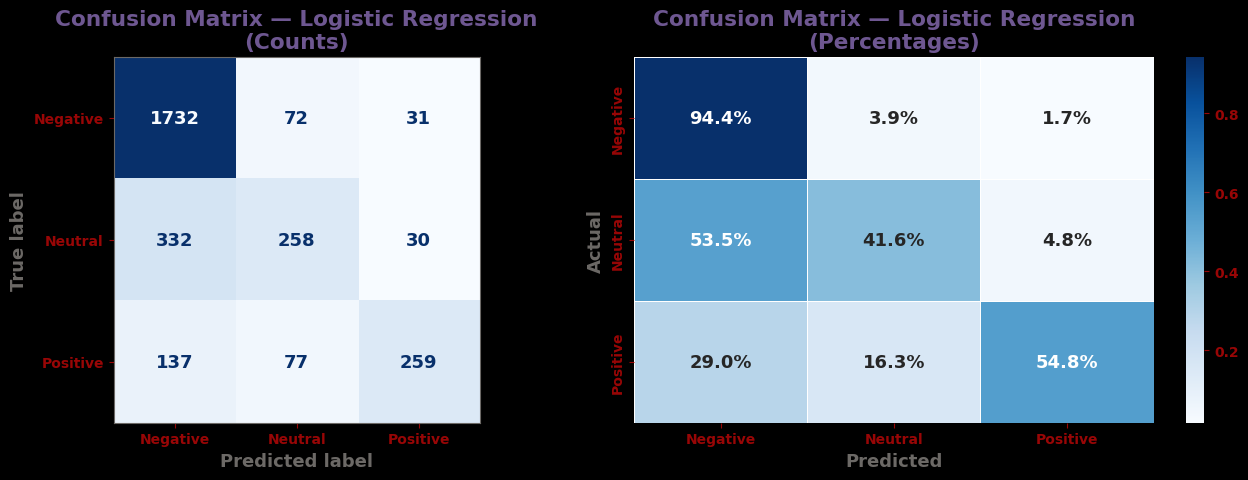

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = results[best_name]['y_pred']
cm          = confusion_matrix(y_test, y_pred_best)
cm_pct      = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative','Neutral','Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}\n(Counts)',
                   color=TITLE, fontweight='bold')

# Percentage
sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'Confusion Matrix — {best_name}\n(Percentages)',
                   color=TITLE, fontweight='bold')
axes[1].set_xlabel('Predicted', color=LABEL)
axes[1].set_ylabel('Actual', color=LABEL)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('model', LogisticRegression( random_state=42, max_iter=1000))
])

param_dist = {
    'tfidf__max_features' : [8000, 10000, 15000],
    'tfidf__ngram_range'  : [(1,1), (1,2), (1,3)],
    'tfidf__min_df'       : [2, 3, 5],
    'model__C'            : [0.1, 0.5, 1.0, 5.0, 10.0],
    'model__solver'       : ['lbfgs', 'saga'],
}

search = RandomizedSearchCV(
    lr_pipeline, param_dist,
    n_iter=20, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train_txt, y_train)

y_pred_tuned = search.best_estimator_.predict(X_test_txt)
tuned_acc    = accuracy_score(y_test, y_pred_tuned)

print(f"\n✅ Best Params   : {search.best_params_}")
print(f"✅ Best CV Acc   : {search.best_score_*100:.2f}%")
print(f"✅ Test Accuracy : {tuned_acc*100:.2f}%")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Negative','Neutral','Positive']))

best_nlp_pipeline = search.best_estimator_
print(f"\n🎯 Final Best Accuracy: {tuned_acc*100:.2f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best Params   : {'tfidf__ngram_range': (1, 3), 'tfidf__min_df': 3, 'tfidf__max_features': 15000, 'model__solver': 'saga', 'model__C': 1.0}
✅ Best CV Acc   : 76.90%
✅ Test Accuracy : 76.88%
              precision    recall  f1-score   support

    Negative       0.79      0.94      0.86      1835
     Neutral       0.64      0.42      0.50       620
    Positive       0.81      0.55      0.65       473

    accuracy                           0.77      2928
   macro avg       0.75      0.64      0.67      2928
weighted avg       0.76      0.77      0.75      2928


🎯 Final Best Accuracy: 76.88%


In [11]:
from transformers import pipeline as hf_pipeline

print("⏳ Loading BERT sentiment model...")
bert_sentiment = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True, max_length=128
)
print("✅ BERT model loaded")
# Test on sample tweets
sample_tweets = [
    "The flight was amazing, crew was so friendly and helpful!",
    "Terrible experience, lost my luggage and no one helped",
    "Flight delayed by 2 hours with no explanation given",
    "Best airline ever, will definitely fly again!",
    "Customer service is absolutely horrible, avoid this airline",
]

print("\n📊 BERT Predictions on Sample Tweets:")
print("─"*65)
for tweet in sample_tweets:
    result = bert_sentiment(tweet)[0]
    emoji  = "😊" if result['label']=='POSITIVE' else "😠"
    print(f"{emoji} [{result['label'].ljust(8)} {result['score']*100:5.1f}%] {tweet[:55]}...")
print("─"*65)

⏳ Loading BERT sentiment model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ BERT model loaded

📊 BERT Predictions on Sample Tweets:
─────────────────────────────────────────────────────────────────
😊 [POSITIVE 100.0%] The flight was amazing, crew was so friendly and helpfu...
😠 [NEGATIVE 100.0%] Terrible experience, lost my luggage and no one helped...
😠 [NEGATIVE 100.0%] Flight delayed by 2 hours with no explanation given...
😊 [POSITIVE 100.0%] Best airline ever, will definitely fly again!...
😠 [NEGATIVE  99.9%] Customer service is absolutely horrible, avoid this air...
─────────────────────────────────────────────────────────────────


In [12]:

print("⏳ Running BERT on 300 test tweets (may take 1-2 min)...")

test_sample = X_test_txt.iloc[:300].tolist()
bert_raw    = bert_sentiment(test_sample, batch_size=32, truncation=True)


def map_bert(label, score):
    if label == 'POSITIVE' and score >= 0.80: return 'positive'
    if label == 'NEGATIVE' and score >= 0.80: return 'negative'
    return 'neutral'

bert_preds  = [map_bert(r['label'], r['score']) for r in bert_raw]
bert_labels = le.transform(bert_preds)
true_labels = y_test.iloc[:300].values

bert_acc = accuracy_score(true_labels, bert_labels)
lr_acc   = accuracy_score(true_labels,
           search.best_estimator_.predict(X_test_txt.iloc[:300]))

print(f"\n📊 Comparison on 300 tweets:")
print(f"  BERT Accuracy       : {bert_acc*100:.2f}%")
print(f"  TF-IDF + LR Accuracy: {lr_acc*100:.2f}%")
print(f"\n  BERT uses zero training on airline data — remarkable!")
print(classification_report(true_labels, bert_labels,
      target_names=['Negative','Neutral','Positive']))

⏳ Running BERT on 300 test tweets (may take 1-2 min)...

📊 Comparison on 300 tweets:
  BERT Accuracy       : 72.00%
  TF-IDF + LR Accuracy: 76.67%

  BERT uses zero training on airline data — remarkable!
              precision    recall  f1-score   support

    Negative       0.79      0.92      0.85       191
     Neutral       0.45      0.07      0.12        69
    Positive       0.52      0.88      0.65        40

    accuracy                           0.72       300
   macro avg       0.59      0.62      0.54       300
weighted avg       0.68      0.72      0.66       300



✅ Prediction Distribution:
predicted_sentiment
negative    10592
neutral      2199
positive     1849
Name: count, dtype: int64

📊 AIRLINE BRAND SENTIMENT SCORECARD
                Total_Tweets  Avg_Score  Positive_Pct  Negative_Pct  Neutral_Pct
airline                                                                         
Virgin America           504     -0.319         0.212         0.532        0.256
Delta                   2222     -0.374         0.186         0.560        0.254
Southwest               2420     -0.402         0.188         0.590        0.221
United                  3822     -0.688         0.096         0.785        0.119
American                2759     -0.690         0.103         0.793        0.105
US Airways              2913     -0.770         0.076         0.846        0.078

🏆 Best Sentiment  : Virgin America
⚠️  Worst Sentiment : US Airways


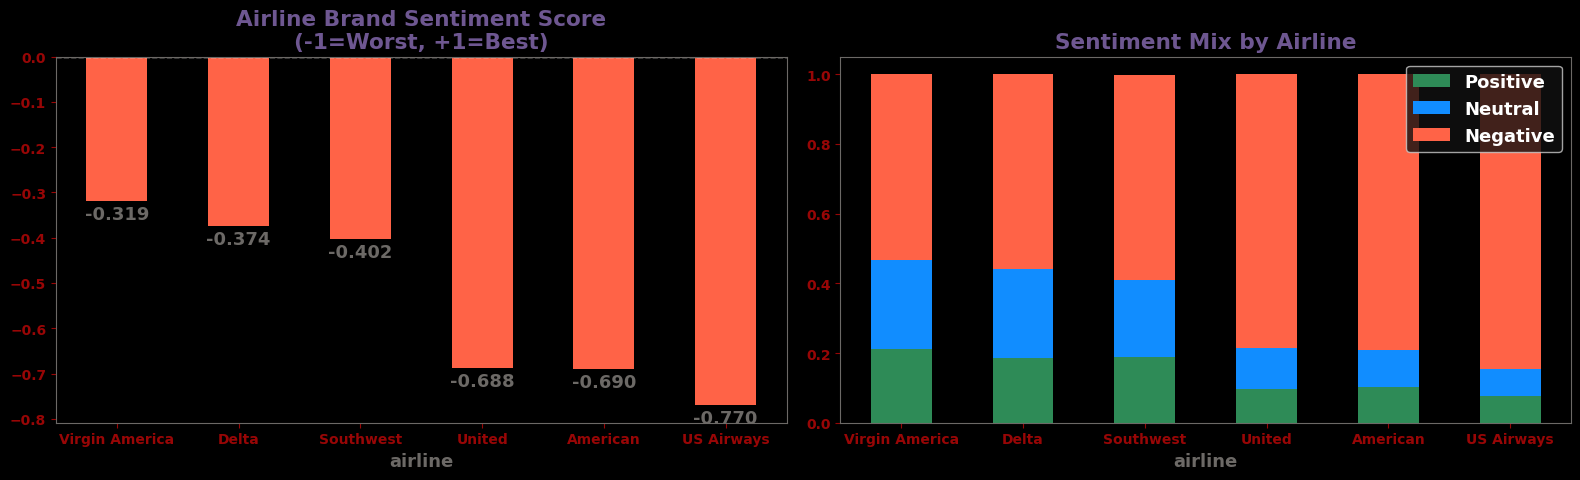

In [13]:

df['predicted_sentiment'] = best_nlp_pipeline.predict(df['clean_text'])


label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
df['predicted_sentiment'] = df['predicted_sentiment'].map(label_map)


df['sentiment_score'] = df['predicted_sentiment'].map({
    'negative': -1, 'neutral': 0, 'positive': 1
})

# Verify
print("✅ Prediction Distribution:")
print(df['predicted_sentiment'].value_counts())

airline_scores = df.groupby('airline').agg(
    Total_Tweets = ('text','count'),
    Avg_Score    = ('sentiment_score','mean'),
    Positive_Pct = ('predicted_sentiment', lambda x: (x=='positive').mean()),
    Negative_Pct = ('predicted_sentiment', lambda x: (x=='negative').mean()),
    Neutral_Pct  = ('predicted_sentiment', lambda x: (x=='neutral').mean()),
).round(3).sort_values('Avg_Score', ascending=False)

print("\n📊 AIRLINE BRAND SENTIMENT SCORECARD")
print("="*70)
print(airline_scores.to_string())
print("="*70)

best_airline  = airline_scores['Avg_Score'].idxmax()
worst_airline = airline_scores['Avg_Score'].idxmin()
print(f"\n🏆 Best Sentiment  : {best_airline}")
print(f"⚠️  Worst Sentiment : {worst_airline}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Brand Score Bar ──
airline_scores['Avg_Score'].plot(
    kind='bar', ax=axes[0],
    color=['seagreen' if s > 0 else 'tomato' for s in airline_scores['Avg_Score']],
    width=0.5)
axes[0].set_title('Airline Brand Sentiment Score\n(-1=Worst, +1=Best)',
                   color=TITLE, fontweight='bold')
axes[0].axhline(y=0, color='white', linestyle='--', linewidth=1)
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=3,
                      color=LABEL, fontweight='bold')

# ── Stacked Sentiment % ──
airline_pct = airline_scores[['Positive_Pct','Neutral_Pct','Negative_Pct']]
airline_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  color=['seagreen','#118DFF','tomato'], width=0.5)
axes[1].set_title('Sentiment Mix by Airline',
                   color=TITLE, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Positive','Neutral','Negative'],
                facecolor='#111111', labelcolor='white')

plt.tight_layout()
plt.show()


In [35]:

ASPECTS = {
    'punctuality'  : ['delay','cancel','late','ontime','landing',
                 'takeoff','departed','arrived','flight'],
    'food'    : ['food','meal','drink','snack','beverage',
                 'lunch','dinner','eating','hungry','taste'],
    'service' : ['staff','crew','rude','helpful','friendly',
                 'attendant','agent','employee','service'],
    'baggage' : ['bag','luggage','lost','baggage','suitcase',
                 'carry','belongings','missing'],
    'seat'    : ['seat','legroom','cramped','comfort',
                 'upgrade','class','space','row'],
    'booking' : ['app','website','checkin','book',
                 'reservation','gate','ticket','boarding'],
}
ASPECT_EMOJI = {
    'flight':'✈️ ','food':'🍽️ ',
    'service':'👨‍✈️ ','baggage':'🧳 ',
    'seat':'💺 ','booking':'📱 ',
}
ROUTING = {
    'flight' : 'Operations — check flight logs',
    'food'   : 'Catering — quality complaint',
    'service': 'HR/Training — staff behaviour',
    'baggage': 'Baggage team — urgent recovery',
    'seat'   : 'Cabin crew — comfort issue',
    'booking': 'IT/Support — system issue',
    'general': 'Customer service — general',
}

def extract_aspect_phrase(tweet, keywords, window=5):
    words   = tweet.lower().split()
    phrases = []
    for i, word in enumerate(words):
        if any(kw in word for kw in keywords):
            start = max(0, i - window)
            end   = min(len(words), i + window + 1)
            phrases.append(' '.join(words[start:end]))
    return max(phrases, key=len) if phrases else tweet

def split_into_clauses(tweet):
    separators = r'\bbut\b|\bhowever\b|\balthough\b|'\
                 r'\bthough\b|\byet\b|\bwhile\b|\bexcept\b|\bdespite\b'
    clauses = re.split(separators, tweet.lower())
    return [c.strip() for c in clauses if len(c.strip()) > 3]

NEGATIONS = ['not','never','no','hardly','barely',
             "wasn't","weren't","didn't","doesn't",
             "isn't","aren't","cant","cannot","won't"]

def handle_negation(text):
    
    words  = text.lower().split()
    result = []
    negate = False
    for word in words:
        if word in NEGATIONS:
            negate = True
            result.append(word)
        elif negate:
            result.append('not_' + word)  # ← "great" → "not_great"
            negate = False
        else:
            result.append(word)
            negate = False
    return ' '.join(result)


def clean_tweet_v2(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = handle_negation(text)          
    return text

def predict_sentiment(tweet_text, pipeline, bert_model=None):
    cleaned     = clean_tweet(tweet_text)
    tfidf_pred  = pipeline.predict([cleaned])[0]
    tfidf_prob  = pipeline.predict_proba([cleaned])[0]
    label_map   = {0:'negative', 1:'neutral', 2:'positive'}
    tfidf_label = label_map.get(tfidf_pred, 'neutral')
    tfidf_conf  = tfidf_prob.max()

    if bert_model:
        bert_raw   = bert_model(tweet_text[:512], truncation=True)[0]
        bert_label = map_bert(bert_raw['label'], bert_raw['score'])
        bert_conf  = bert_raw['score']
    else:
        bert_label = 'N/A'
        bert_conf  = 0


    if bert_label == 'N/A':
        final_label = tfidf_label
        final_conf  = tfidf_conf
        final_model = 'TF-IDF + LR'
    elif bert_label == tfidf_label:
        final_label = tfidf_label
        final_conf  = max(tfidf_conf, bert_conf)
        final_model = 'Both Agree'
    elif bert_conf >= 0.70:
        final_label = bert_label    
        final_conf  = bert_conf
        final_model = 'BERT (overrode TF-IDF)'
    else:
        final_label = tfidf_label   
        final_conf  = tfidf_conf
        final_model = 'TF-IDF + LR (BERT uncertain)'

    return {
        'tfidf_label' : tfidf_label,
        'tfidf_conf'  : tfidf_conf,
        'tfidf_probs' : dict(zip(label_map.values(), tfidf_prob.round(3))),
        'bert_label'  : bert_label,
        'bert_conf'   : bert_conf,
        'final_label' : final_label,   
        'final_conf'  : final_conf,    
        'final_model' : final_model,   
        'cleaned_text': cleaned,
    }

def show_sentiment_result(tweet, result):
    emoji_map   = {'negative':'😠','neutral':'😐','positive':'😊'}
    tfidf_emoji = emoji_map.get(result['tfidf_label'], '❓')
    bert_emoji  = emoji_map.get(result['bert_label'],  '❓')
    final_emoji = emoji_map.get(result['final_label'], '❓')

    
    if result['tfidf_label'] == result['bert_label']:
        agreement = '✅ Both models agree'
    else:
        agreement = f"⚠️  Conflict → {result['final_model']}"

    
    rows = [
        {
            'Model'     : 'TF-IDF + LR',
            'Sentiment' : f"{tfidf_emoji} {result['tfidf_label'].upper()}",
            'Confidence': f"{result['tfidf_conf']*100:.1f}%",
            'Trusted'   : '✅' if result['final_model'] in
                          ['TF-IDF + LR','Both Agree',
                           'TF-IDF + LR (BERT uncertain)'] else '❌ Overridden',
        },
        {
            'Model'     : 'BERT',
            'Sentiment' : f"{bert_emoji} {result['bert_label'].upper()}",
            'Confidence': f"{result['bert_conf']*100:.1f}%",
            'Trusted'   : '✅' if result['final_model'] in
                          ['BERT (overrode TF-IDF)','Both Agree'] else '⚠️ Low conf',
        },
    ]
    df_models = pd.DataFrame(rows)

    
    prob_rows = [
        {
            'Class'      : f"{emoji_map.get(lbl,'')} {lbl.capitalize()}",
            'Probability': f"{prob*100:.1f}%",
            'Bar'        : '█' * int(prob * 30),
        }
        for lbl, prob in sorted(
            result['tfidf_probs'].items(), key=lambda x: -x[1])
    ]
    df_probs = pd.DataFrame(prob_rows)

    
    insight = {
        'negative': ('HIGH',   '⚠️  Flag for customer service follow-up'),
        'neutral' : ('MEDIUM', '👀 Monitor — opportunity to engage'),
        'positive': ('LOW',    '✅ Amplify — share to boost brand image'),
    }.get(result['final_label'], ('MEDIUM', '👀 Monitor'))

    print("\n" + "━"*65)
    print(f"  ✈️  TWEET SENTIMENT RESULT")
    print("━"*65)
    print(f"  📝 Tweet    : {tweet[:65]}")
    print(f"  🧹 Cleaned  : {result['cleaned_text'][:65]}")
    print(f"  🤝 Status   : {agreement}")
    print("─"*65)
    print("  🤖 Model Predictions:")
    print(df_models.to_string(index=False))
    print("─"*65)
    print("  📊 TF-IDF Class Probabilities:")
    print(df_probs.to_string(index=False))
    print("─"*65)
    print(f"  🎯 Final Decision : {final_emoji} {result['final_label'].upper()}"
          f"  ({result['final_conf']*100:.1f}% confident)")
    print(f"  💡 Priority       : {insight[0]}")
    print(f"  💡 Action         : {insight[1]}")
    print("━"*65)

print("✅ Updated predict_sentiment + show_sentiment_result ready")

     

✅ Updated predict_sentiment + show_sentiment_result ready


In [36]:
example_tweets = [
    "@UnitedAirlines lost my bag AGAIN. Third time this year. Absolutely furious!",
    "Just landed in NYC. Flight was on time and crew was super friendly 😊",
    "@Delta flight delayed by 30 mins. Not ideal but these things happen I guess.",
    "Never flying @SouthwestAir again. Rude staff and cramped seats. Awful experience!",
    "Upgraded to first class for free! @AmericanAir you made my day! Thank you!",
]

absa_examples = [
    "its awesome but the food is absolutely horrible",
    "crew was so friendly but flight got delayed 3 hours",
    "lost my luggage again horrible experience",
    "seat was cramped but service was excellent",
    "amazing flight great food friendly crew best airline ever",
    "rude staff cancelled flight lost bag worst experience ever",
]

print("\n" + "="*55)
print("  ✈️  TWEET SENTIMENT PREDICTION SYSTEM")
print("="*55)

while True:
    print("\n1.  Predict single tweet")
    print("2.  Predict multiple tweets")
    print("3.  Run sentiment examples")
    print("4.  Airline brand scorecard")
    print("5.  Aspect analysis (ABSA) — single tweet")
    print("6.  Aspect analysis (ABSA) — multiple tweets")
    print("7.  Run ABSA examples")
    print("8.  Exit")
    choice = input("\nSelect option (1-8): ").strip()

    if choice == '1':
        tweet = input("\nEnter tweet: ").strip()
        if tweet:
            result = predict_sentiment(tweet, best_nlp_pipeline, bert_sentiment)
            show_sentiment_result(tweet, result)
        else:
            print("❌ Please enter a tweet.")

    elif choice == '2':
        n = int(input("How many tweets [3]: ").strip() or 3)
        batch = []
        for i in range(n):
            tweet = input(f"Tweet {i+1}: ").strip()
            if tweet:
                result = predict_sentiment(tweet, best_nlp_pipeline, bert_sentiment)
                show_sentiment_result(tweet, result)
                batch.append({
                    'Tweet'     : tweet[:35]+'...',
                    'Sentiment' : result['tfidf_label'].upper(),
                    'Confidence': f"{result['tfidf_conf']*100:.1f}%",
                    'BERT'      : result['bert_label'].upper(),
                })
        if batch:
            print("\n📋 BATCH SUMMARY:")
            df_batch = pd.DataFrame(batch)
            print(df_batch.to_string(index=False))
            print("\n📊 Sentiment Counts:")
            print(df_batch['Sentiment'].value_counts().reset_index()
                  .rename(columns={'index':'Sentiment','Sentiment':'Count'})
                  .to_string(index=False))

    elif choice == '3':
        for tweet in example_tweets:
            result = predict_sentiment(tweet, best_nlp_pipeline, bert_sentiment)
            show_sentiment_result(tweet, result)

    elif choice == '4':
        print("\n📊 AIRLINE BRAND SCORECARD:")
        print(airline_scores[['Total_Tweets','Avg_Score',
                               'Positive_Pct','Negative_Pct']].to_string())
        print(f"\n  🏆 Best  : {airline_scores['Avg_Score'].idxmax()}")
        print(f"  ⚠️  Worst : {airline_scores['Avg_Score'].idxmin()}")

    elif choice == '5':
        tweet = input("\nEnter tweet for ABSA: ").strip()
        if tweet:
            show_absa(tweet)
        else:
            print("❌ Please enter a tweet.")

    elif choice == '6':
        n = int(input("How many tweets [3]: ").strip() or 3)
        all_dfs = []
        for i in range(n):
            tweet = input(f"Tweet {i+1}: ").strip()
            if tweet:
                all_dfs.append(show_absa(tweet))
        if all_dfs:
            print("\n📋 COMBINED ABSA SUMMARY:")
            combined = pd.concat(all_dfs, ignore_index=True)
            print(combined.to_string(index=False))

    elif choice == '7':
        all_dfs = []
        for tweet in absa_examples:
            all_dfs.append(show_absa(tweet))
        print("\n📊 MASTER SUMMARY:")
        master = pd.concat(all_dfs, ignore_index=True)
        print(master[['Aspect','Sentiment','Confidence','Action']].to_string(index=False))
        print("\n📈 ASPECT COMPLAINT RATE:")
        neg_rate = master.groupby('Aspect').apply(
            lambda x: round(x['Sentiment'].str.contains('Negative').sum()
                            / len(x) * 100, 1)
        ).sort_values(ascending=False).reset_index()
        neg_rate.columns = ['Aspect','Negative_%']
        neg_rate['Bar']  = neg_rate['Negative_%'].apply(lambda x: '█'*int(x/5))
        print(neg_rate.to_string(index=False))

    elif choice == '8':
        print("\nExiting. Goodbye! 👋")
        break
    else:
        print("Invalid — enter 1 to 8.")


  ✈️  TWEET SENTIMENT PREDICTION SYSTEM

1.  Predict single tweet
2.  Predict multiple tweets
3.  Run sentiment examples
4.  Airline brand scorecard
5.  Aspect analysis (ABSA) — single tweet
6.  Aspect analysis (ABSA) — multiple tweets
7.  Run ABSA examples
8.  Exit



Select option (1-8):  1

Enter tweet:  not great flight



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✈️  TWEET SENTIMENT RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📝 Tweet    : not great flight
  🧹 Cleaned  : not great flight
  🤝 Status   : ⚠️  Conflict → BERT (overrode TF-IDF)
─────────────────────────────────────────────────────────────────
  🤖 Model Predictions:
      Model  Sentiment Confidence      Trusted
TF-IDF + LR 😊 POSITIVE      91.8% ❌ Overridden
       BERT 😠 NEGATIVE     100.0%            ✅
─────────────────────────────────────────────────────────────────
  📊 TF-IDF Class Probabilities:
     Class Probability                         Bar
😊 Positive       91.8% ███████████████████████████
😠 Negative        4.1%                           █
 😐 Neutral        4.1%                           █
─────────────────────────────────────────────────────────────────
  🎯 Final Decision : 😠 NEGATIVE  (100.0% confident)
  💡 Priority       : HIGH
  💡 Action         : ⚠️  Flag for customer se


Select option (1-8):  5

Enter tweet for ABSA:  great flight not 



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📝 Tweet   : great flight not
  🧹 Cleaned : great flight not
  🎯 Overall : 😠 Mostly Negative
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     Aspect  Sentiment Confidence           Phrase   Action         Route To
Punctuality 😠 Negative      93.5% great flight not ⚠️  Flag Customer service
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1.  Predict single tweet
2.  Predict multiple tweets
3.  Run sentiment examples
4.  Airline brand scorecard
5.  Aspect analysis (ABSA) — single tweet
6.  Aspect analysis (ABSA) — multiple tweets
7.  Run ABSA examples
8.  Exit



Select option (1-8):  8



Exiting. Goodbye! 👋
